In [5]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd



In [13]:
start = dt.date(2000, 1, 1)
end = dt.date(2024, 12, 31)
signal_name = "IS2"
price_filter = 5
IC = 0.05

data = sfd.load_assets(
    start=start,
    end=end,
    columns=[
        "date",
        "barrid",
        "price",
        "return",
        "specific_risk",
        "predicted_beta",
        "market_cap",
        "daily_volume", 
        "specific_return"
    ],
    in_universe=True,
).with_columns(pl.col("return",  "specific_return", "specific_risk").truediv(100))

# T=5
# days=T*21

df = data.sort(["barrid", "date"])


# calculates turnover 
df = df.with_columns(
    (pl.col("daily_volume") / pl.col("market_cap")).alias("turnover")
)

# Get last trading day of each month per stock
df = df.with_columns([
    pl.col("date").cast(pl.Datetime).alias("date_dt"),
    pl.col("market_cap").log().alias("log_mktcap")
])

# Create month indicator
df = df.with_columns(
    (pl.col("date_dt").dt.year() * 100 + pl.col("date_dt").dt.month()).alias("yyyymm")
)
print("check1")

# last trading day per month
monthly_df = df.group_by(["barrid", "yyyymm"]).agg([
    pl.col("specific_return").last().alias("specific_return"),
    pl.col("turnover").mean().alias("turnover"),
    pl.col("log_mktcap").last().alias("log_mktcap"),
    pl.col("price").last().alias("price"),
    pl.col("predicted_beta").last().alias("predicted_beta"),
    pl.col("specific_risk").last().alias("specific_risk"),
    pl.col("date").last().alias("date"),
    pl.col("return").last().alias("return")
])

# We'll shift by 1 month to skip last month
T = 60
monthly_df = monthly_df.sort(["barrid","yyyymm"])

monthly_df = monthly_df.with_columns([
    # MOMENTUM
    pl.col("specific_return").log1p().shift(1).rolling_sum(window_size=T).over("barrid").alias("mom_12m"),
    
    # volitility
    pl.col("specific_return").shift(1).rolling_std(window_size=T).over("barrid").alias("vol_12m"),
    
    # Skewness
    pl.col("specific_return").shift(1).rolling_skew(window_size=T).over("barrid").alias("skew_12m"),
    
    # Turnover
    pl.col("turnover").shift(1).rolling_mean(window_size=T).over("barrid").alias("turn_12m")
])
print('check2')

# Drop rows with missing values
monthly_df = monthly_df.drop_nulls(["mom_12m", "vol_12m", "skew_12m", "turn_12m", "log_mktcap"])
print('check3')
# ols per mounth
def cross_sectional_ols(df_month):
    X = df_month[["skew_12m","vol_12m","mom_12m","turn_12m","log_mktcap"]]
    y = df_month["specific_return"]  
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model.params

# Shift skew by -1 month to get next month skew
monthly_df = monthly_df.sort(["barrid","yyyymm"])
monthly_df = monthly_df.with_columns(
    pl.col("skew_12m").shift(-1).over("barrid").alias("skew_next")  
)

monthly_df = monthly_df.drop_nulls(["skew_next"])

# run cross-sectional regression
coeffs_list = []

for month, df_month in monthly_df.group_by("yyyymm"):
    df_month_pd = df_month.to_pandas()
    params = cross_sectional_ols(df_month_pd)
    coeffs_list.append(params)

coeffs_df = pd.DataFrame(coeffs_list)
print('check4')
# average coefficients over months
avgcoeffs = coeffs_df.mean()

print(avgcoeffs)

# Compute expected skewness using past characteristics
monthly_df = monthly_df.with_columns(
    (
        avgcoeffs["const"]
        + avgcoeffs["skew_12m"] * pl.col("skew_12m")
        + avgcoeffs["vol_12m"] * pl.col("vol_12m")
        + avgcoeffs["mom_12m"] * pl.col("mom_12m")
        + avgcoeffs["turn_12m"] * pl.col("turn_12m")
        + avgcoeffs["log_mktcap"] * pl.col("log_mktcap")
    ).alias(signal_name)
)

check1
check2
check3
check4
const        -0.007437
skew_12m     -0.000053
vol_12m       0.028815
mom_12m       0.001129
turn_12m      0.051756
log_mktcap    0.000318
dtype: float64


In [7]:
monthly_df

barrid,yyyymm,specific_return,turnover,log_mktcap,price,predicted_beta,specific_risk,date,return,mom_12m,vol_12m,skew_12m,turn_12m,skew_next,IS2
str,i32,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64,f64,f64
"""USA06Z1""",201807,-0.02731,0.00253,19.972277,4.25,1.428083,0.731809,2018-07-31,-0.007009,0.346244,0.026868,1.035369,0.000358,1.009348,0.000047
"""USA06Z1""",201808,0.02558,0.001242,20.193065,5.3,1.446746,0.754194,2018-08-31,0.033138,0.326465,0.027155,1.009348,0.000397,0.975102,0.000106
"""USA06Z1""",201809,0.02931,0.001185,20.346677,6.18,1.503573,0.73734,2018-09-28,0.024876,0.379259,0.026922,0.975102,0.000415,0.910495,0.000211
"""USA06Z1""",201810,0.02879,0.000979,20.286659,5.82,1.515279,0.747799,2018-10-31,0.012174,0.422795,0.026932,0.910495,0.000426,0.872293,0.000245
"""USA06Z1""",201811,0.03821,0.024455,19.5514,2.79,0.988852,0.873214,2018-11-29,0.037175,0.44005,0.027069,0.872293,0.000437,0.879122,0.000037
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBETH1""",202409,-0.00187,0.000184,20.52703,16.69,1.042124,0.213448,2024-09-30,0.018304,-0.012338,0.017771,0.035449,0.000103,-0.035408,-0.000404
"""USBETH1""",202410,-0.01095,0.000116,20.467071,15.7,1.064896,0.211529,2024-10-31,-0.029066,-0.051776,0.017044,-0.035408,0.000105,-0.002608,-0.000484
"""USBETH1""",202411,-0.00464,0.000117,20.565018,17.31,1.088064,0.213486,2024-11-29,-0.014798,-0.088999,0.016711,-0.002608,0.000106,-0.018322,-0.000506


In [27]:
signal= monthly_df.with_columns(
    pl.col("IS2").rank(method="average").over("date").alias("rank"))

signal = signal.with_columns(
    pl.count("IS2").over("date").alias("count_per_date"))

signal = signal.with_columns(
    ((pl.col("rank") / pl.col("count_per_date") * 5).ceil().cast(pl.Int32)).alias("quintile"))

signal = signal.drop(["rank", "count_per_date"])
signal.describe()
signal= signal.filter(pl.col("quintile").is_not_null())
signal

barrid,yyyymm,specific_return,turnover,log_mktcap,price,predicted_beta,specific_risk,date,return,mom_12m,vol_12m,skew_12m,turn_12m,skew_next,IS2,quintile
str,i32,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64,f64,f64,i32
"""USA06Z1""",201807,-0.02731,0.00253,19.972277,4.25,1.428083,0.731809,2018-07-31,-0.007009,0.346244,0.026868,1.035369,0.000358,1.009348,0.000047,3
"""USA06Z1""",201808,0.02558,0.001242,20.193065,5.3,1.446746,0.754194,2018-08-31,0.033138,0.326465,0.027155,1.009348,0.000397,0.975102,0.000106,4
"""USA06Z1""",201809,0.02931,0.001185,20.346677,6.18,1.503573,0.73734,2018-09-28,0.024876,0.379259,0.026922,0.975102,0.000415,0.910495,0.000211,4
"""USA06Z1""",201810,0.02879,0.000979,20.286659,5.82,1.515279,0.747799,2018-10-31,0.012174,0.422795,0.026932,0.910495,0.000426,0.872293,0.000245,4
"""USA06Z1""",201811,0.03821,0.024455,19.5514,2.79,0.988852,0.873214,2018-11-29,0.037175,0.44005,0.027069,0.872293,0.000437,0.879122,0.000037,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBETH1""",202409,-0.00187,0.000184,20.52703,16.69,1.042124,0.213448,2024-09-30,0.018304,-0.012338,0.017771,0.035449,0.000103,-0.035408,-0.000404,1
"""USBETH1""",202410,-0.01095,0.000116,20.467071,15.7,1.064896,0.211529,2024-10-31,-0.029066,-0.051776,0.017044,-0.035408,0.000105,-0.002608,-0.000484,1
"""USBETH1""",202411,-0.00464,0.000117,20.565018,17.31,1.088064,0.213486,2024-11-29,-0.014798,-0.088999,0.016711,-0.002608,0.000106,-0.018322,-0.000506,1


/tmp/ipykernel_569336/3513563934.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


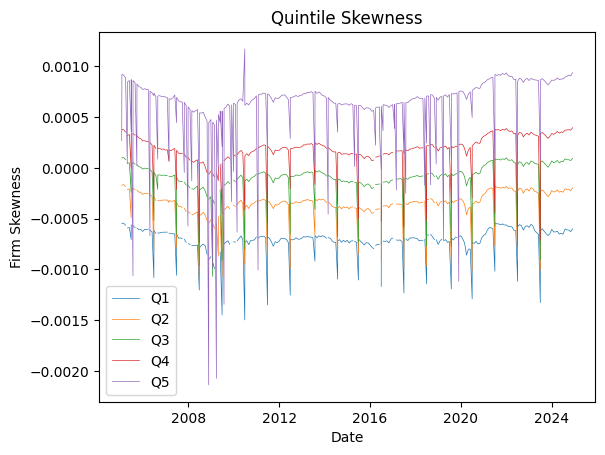

In [30]:
raw = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
        values="IS2",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

dates= raw['date']

for col in raw.columns:
    if col != "date":
        plt.plot(dates, raw[col], label=f"Q{col}", linewidth=0.5)

plt.legend()
plt.xlabel("Date")

plt.ylabel("Firm Skewness")
plt.title("Quintile Skewness")
plt.show()

In [25]:
ew = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
        values="IS2",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

/tmp/ipykernel_569336/3151554960.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


/tmp/ipykernel_569336/430862856.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(


shape: (291, 7)
┌────────────┬───────────┬───────────┬───────────┬──────────┬───────────┬───────────┐
│ date       ┆ 1         ┆ 2         ┆ 3         ┆ 4        ┆ 5         ┆ spread    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 2005-01-28 ┆ null      ┆ null      ┆ null      ┆ null     ┆ -0.008886 ┆ null      │
│ 2005-01-31 ┆ 0.015287  ┆ 0.015731  ┆ 0.015829  ┆ 0.013227 ┆ 0.003838  ┆ 0.011448  │
│ 2005-02-28 ┆ 0.008901  ┆ 0.011175  ┆ 0.011818  ┆ 0.005814 ┆ -0.001116 ┆ 0.010017  │
│ 2005-03-31 ┆ 0.005025  ┆ 0.010133  ┆ 0.014032  ┆ 0.009807 ┆ 0.000041  ┆ 0.004984  │
│ 2005-04-28 ┆ null      ┆ null      ┆ null      ┆ null     ┆ -0.012919 ┆ null      │
│ …          ┆ …         ┆ …         ┆ …         ┆ …        ┆ …         ┆ …         │
│ 2024-07-31 ┆ -0.473598 ┆ -0.008913 ┆

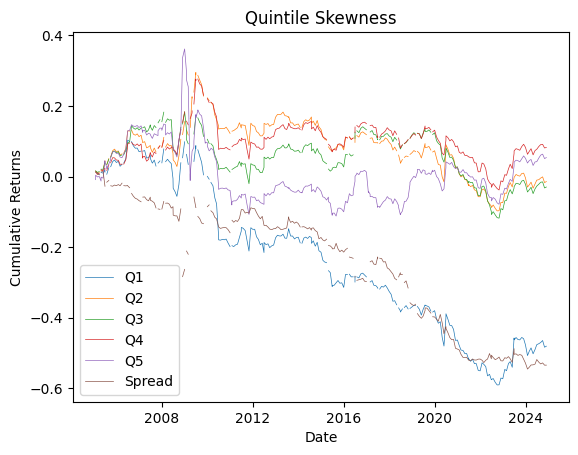

In [26]:
signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])
signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
        values="cum_ret",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
print(ew)

dates= ew['date']

for col in ew.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()